In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from clonalg.model.clonalg_classification import ClassificationClonalg

In [3]:
dataset = load_digits()

X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train / 16.0
X_test = X_test / 16.0

In [27]:
classifier = ClassificationClonalg(
    n_classes=10,
    population_size=100,
    clone_factor=0.3,
    n_select=10,
    n_replace=20,
    n_generations=100,
    memory_size=10,
    rho=10,
    bounds=(0, 1.0)
)

In [28]:
classifier.fit(X_train, y_train)

100%|██████████| 10/10 [00:18<00:00,  1.81s/it]


In [29]:
from sklearn.metrics import classification_report

predictions = classifier.predict_batch(X_test, k=3)

string_target_names = [str(name) for name in dataset.target_names]

print(classification_report(y_test, predictions, target_names=string_target_names, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      0.96      0.98        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.94      0.96        47
           6       0.97      1.00      0.99        35
           7       1.00      1.00      1.00        34
           8       0.97      1.00      0.98        30
           9       0.95      0.95      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.99      0.98       360
weighted avg       0.98      0.98      0.98       360



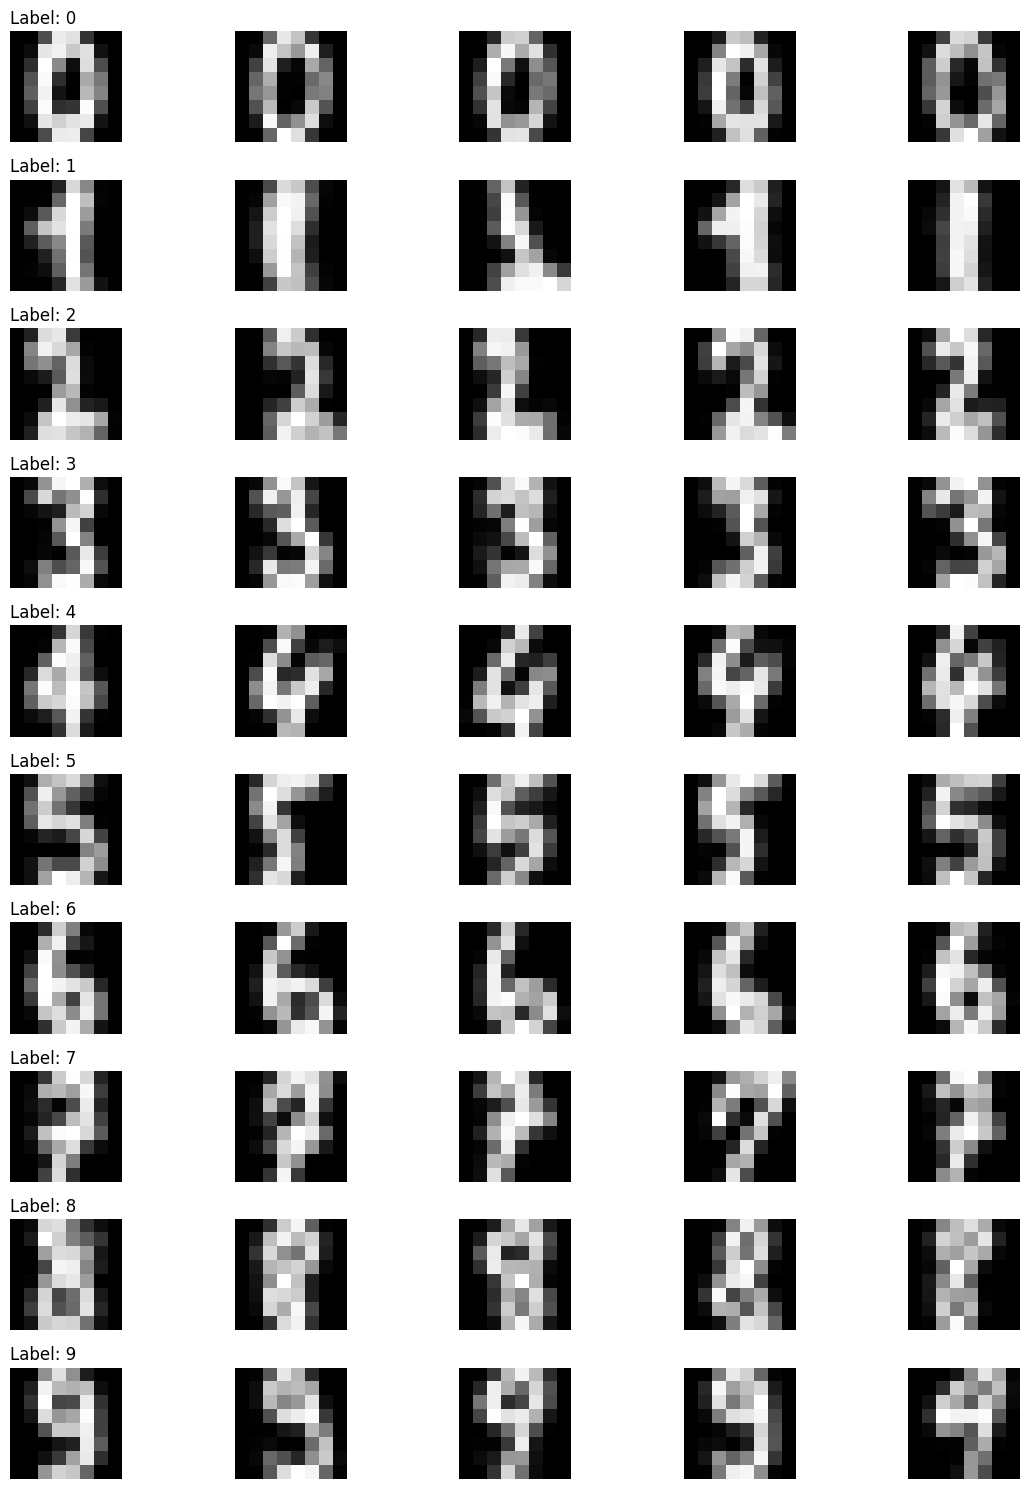

In [30]:
import matplotlib.pyplot as plt

IMG_SHAPE = (8, 8) 
N_CELLS_TO_SHOW = 5

fig, axes = plt.subplots(
    classifier.n_classes, 
    N_CELLS_TO_SHOW, 
    figsize=(12, 1.5 * classifier.n_classes)
)

for label in range(classifier.n_classes):
    memory_matrix = classifier.models[label]
    
    for i in range(N_CELLS_TO_SHOW):
        ax = axes[label, i]
        if i < len(memory_matrix):
            img = memory_matrix[i].reshape(IMG_SHAPE)
            ax.imshow(img, cmap='gray')
        
        ax.axis('off')
        
        if i == 0:
            ax.set_title(f"Label: {label}", fontsize=12, loc='left')

plt.tight_layout()
plt.show()